# Simulazione Interattiva: Cavità + 2 Qubit nel Regime USC
## Controllo Ottimo Quantistico Ibrido (CRAB + GRAPE + PCHIP)

Questo notebook implementa e visualizza la generazione deterministica di stati non-classici della cavità sfruttando l'**Effetto Casimir Dinamico (DCE)** in un sistema con **due qubit superconduttori accoppiati indipendentemente** a un modo elettromagnetico di cavità nel regime di accoppiamento ultrastro (USC, $g_1 = g_2 = 0.3\omega_c$).

### Struttura del Notebook:
1. **Setup & Import Moduli**: Inizializzazione librerie e caricamento moduli core del progetto (`two_qubit_system.py`, `crab_optimizer.py`, `grape_optimizer.py`).
2. **Parametri Fisici & Modello**: Costruzione del sistema 2 qubit (spazio di Hilbert $dim=30 \times 2 \times 2 = 120$) e scelta dello stato target.
3. **Fase 1: Ottimizzazione CRAB**: Ricerca globale gradient-free con serie di Fourier troncate su 2 controlli $\Omega_{D1}(t)$ e $\Omega_{D2}(t)$.
4. **Analisi Dinamica CRAB**: Evoluzione $\langle n \rangle(t)$, forme d'onda dei drive, spettri FFT e funzioni di Wigner.
5. **Fase 2: Raffinamento GRAPE (L-BFGS-B)**: Ottimizzazione gradient-based ad alta precisione con warm-start da CRAB.
6. **Fase 3: Lisciamento PCHIP**: Interpolazione spline cubica per eliminare i gradini discreti e confronto finale fedeltà/costo.
7. **Caricamento Risultati Batch (Opzionale)**: Lettura diretta dei dati precomputati da `run_full_pipeline_2q.py`.

### 1. Setup e Import Moduli

In [4]:
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from qutip import sesolve, expect, ptrace, fidelity, wigner, ket2dm

# Stile grafici Matplotlib per figure chiare stile articolo
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 13,
})

# Import dei moduli core del progetto
from two_qubit_system import (
    build_two_qubit_system,
    target_fock_2q,
    target_squeezed_2q,
    target_cat_2q,
    target_bell_2q,
    grape_target_fock_2q,
    grape_target_squeezed_2q,
    grape_target_cat_2q,
    make_crab_cost_cavity,
    compute_control_cost,
    db_to_r,
)
from crab_optimizer import CRABOptimizer
from grape_optimizer import GRAPEOptimizer

print("Moduli importati correttamente!")


Moduli importati correttamente!


### 2. Parametri Fisici e Costruzione del Sistema a 2 Qubit

In [5]:
# --- Parametri Fisici ---
dim = 40              # Troncamento spazio di Fock cavità
omega_c = 1.0         # Frequenza della cavità (unità di riferimento)
g1 = 0.3              # Accoppiamento cavità-qubit 1 (regime USC)
g2 = 0.3              # Accoppiamento cavità-qubit 2 (regime USC)
omega_bases = [2.0, 2.0]  # Frequenza centrale del drive per i due qubit

tau_s = np.pi / (2 * g1)  # Scala dei tempi caratteristica (semi-oscillazione Rabi)
T = 10 * tau_s            # Durata totale dell'evoluzione
Nt = 400                  # Punti griglia temporale per CRAB
tlist = np.linspace(0, T, Nt)
dt = tlist[1] - tlist[0]

# Costruzione del sistema 2 qubit (Hamiltoniana di drift H0 e controlli H1, H2)
sys2q = build_two_qubit_system(dim=dim, omega_c=omega_c, g1=g1, g2=g2)

print(f"Dimensione spazio di Hilbert totale: {sys2q.H0.shape[0]} (dim={dim} x 2 x 2)")
print(f"Numero di controlli indipendenti: {len(sys2q.H_controls)}")
print(f"Durata evoluzione: T = {T:.2f} ({T/tau_s:.1f} tau_s)")


Dimensione spazio di Hilbert totale: 160 (dim=40 x 2 x 2)
Numero di controlli indipendenti: 2
Durata evoluzione: T = 52.36 (10.0 tau_s)


### 3. Definizione dello Stato Target

In [6]:
# Scegli lo stato target (decommenta quello desiderato):

# Opzione 1: Stato di Fock |n=6> (benchmark principale del paper)
n_target = 10
target_state = target_fock_2q(dim, n=n_target, trace_over_qubits=True)
target_label = f"Fock |n={n_target}>"

# Opzione 2: Stato Squeezed (es. 3 dB, theta = pi/4)
# r = db_to_r(3.0)
# target_state = target_squeezed_2q(dim, r=r, theta=np.pi/4, trace_over_qubits=True)
# target_label = "Squeezed (3 dB, theta=pi/4)"

# Opzione 3: Cat state superposition
# target_state = target_cat_2q(dim, alpha=2.0, trace_over_qubits=True)
# target_label = "Cat State (alpha=2.0)"

# Funzione costo per CRAB (infedeltà sulla matrice densità ridotta della cavità)
cost_fn = make_crab_cost_cavity(target_state)

print(f"Stato target selezionato: {target_label}")


Stato target selezionato: Fock |n=10>


### 4. Fase 1: Ottimizzazione CRAB (Gradient-Free)

In [7]:
num_freqs = 20  # Numero di frequenze per controllo (2 x 20 x 2 = 80 parametri)

optimizer_crab = CRABOptimizer(
    H_drift=sys2q.H0,
    H_controls=sys2q.H_controls,
    T=T,
    num_tslots=Nt,
    num_freqs=num_freqs,
    omega_bases=omega_bases,
    freq_range=(0, 3 * omega_c),
    basis_type="uniform",
    seed=39,  # Cambia seed o imposta None per un run diverso
)

print("Avvio ottimizzazione CRAB (Nelder-Mead)...")
t0 = time.time()
res_crab = optimizer_crab.optimize(
    psi0=sys2q.psi0_ket,
    cost_function=cost_fn,
    max_iter=None,
    method="Nelder-Mead",
)
t_crab = time.time() - t0

control_q1_crab = res_crab.control_pulses[0]
control_q2_crab = res_crab.control_pulses[1]

# Calcolo fedeltà della cavità
rho_cav_crab = ptrace(res_crab.final_state, 0)
F_crab = fidelity(target_state, rho_cav_crab)
C2_crab = compute_control_cost([control_q1_crab, control_q2_crab], dt)

print("\n=== Risultati CRAB ===")
print(f"Fedeltà cavità: F = {F_crab:.6f}")
print(f"Costo energetico C^2: {C2_crab:.2f}")
print(f"Tempo impiegato: {t_crab:.1f} secondi")
print(f"Stato ottimizzazione: {res_crab.message}")


Avvio ottimizzazione CRAB (Nelder-Mead)...

=== Risultati CRAB ===
Fedeltà cavità: F = 0.943840
Costo energetico C^2: 744.24
Tempo impiegato: 1252.3 secondi
Stato ottimizzazione: Maximum number of function evaluations has been exceeded.


### 5. Analisi Dinamica e Grafici (CRAB)

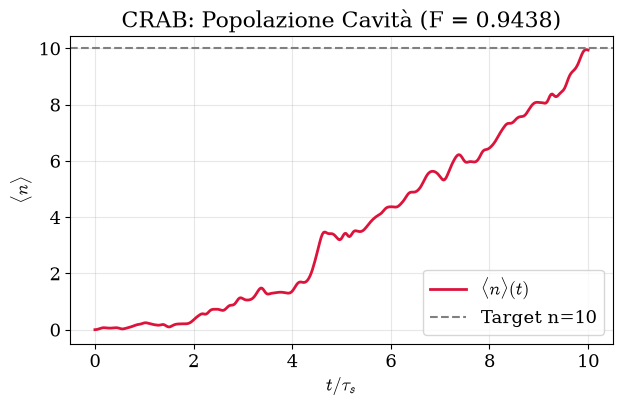

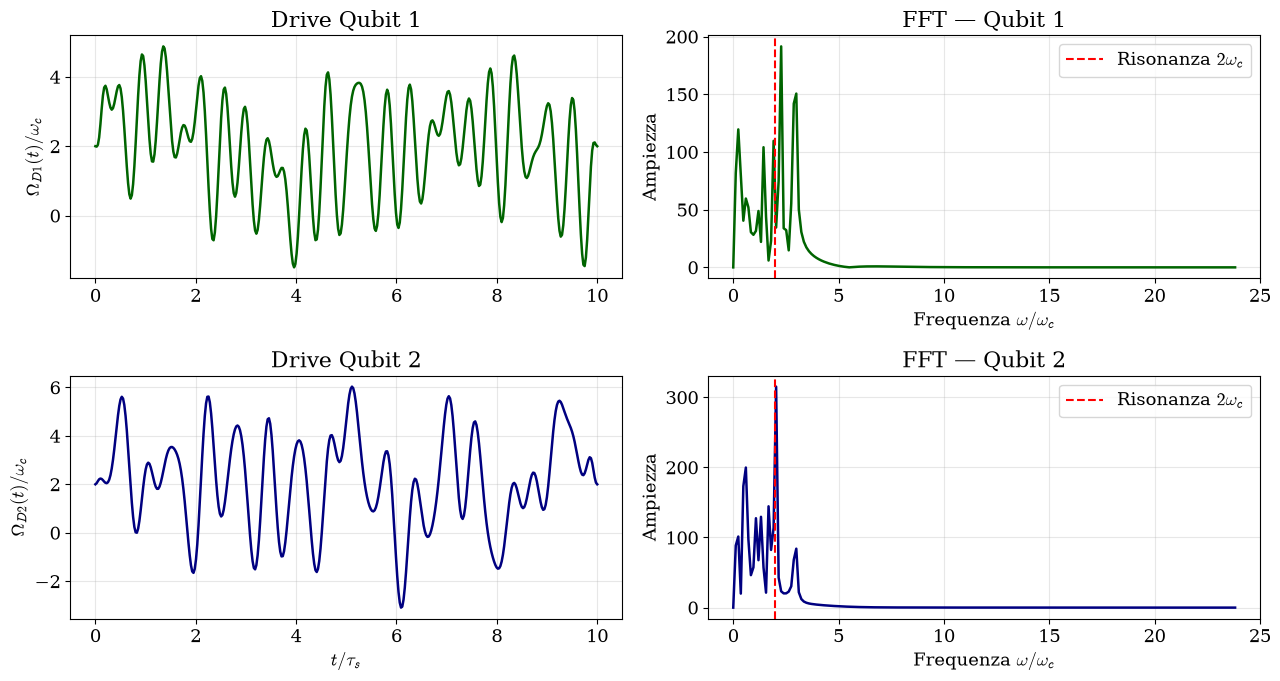

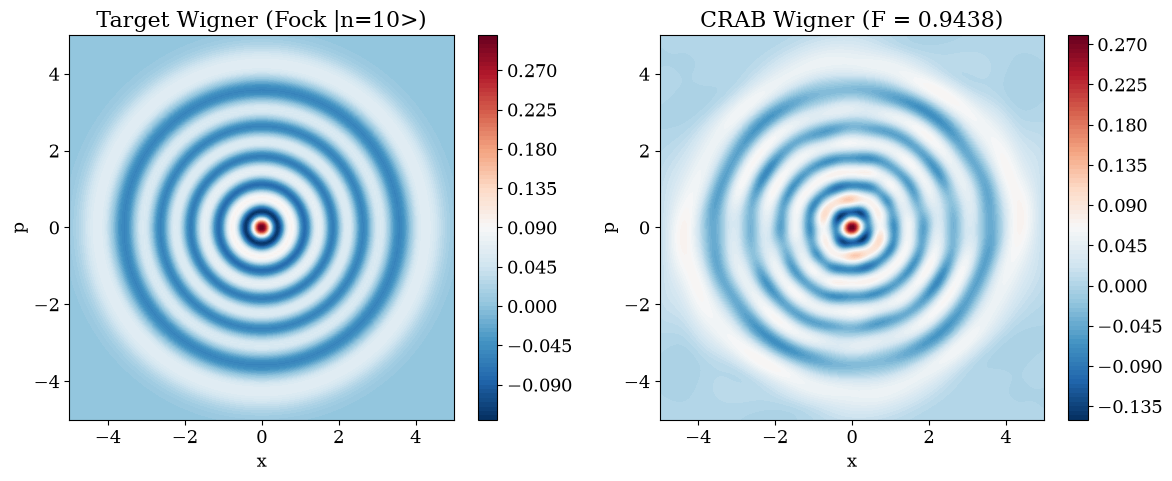

In [8]:
# Evoluzione temporale completa dello stato con i polsi ottimali
H_total_crab = [
    sys2q.H0,
    [sys2q.H_controls[0], control_q1_crab],
    [sys2q.H_controls[1], control_q2_crab],
]
res_evol_crab = sesolve(H_total_crab, sys2q.psi0_ket, tlist)
states_crab = res_evol_crab.states
n_expect_crab = [expect(sys2q.n_tot, psi) for psi in states_crab]

# Plot della popolazione fotonica <n>(t)
plt.figure(figsize=(7, 4))
plt.plot(tlist / tau_s, n_expect_crab, "crimson", lw=2, label=r"$\langle n \rangle(t)$")
if "Fock" in target_label:
    plt.axhline(n_target, color="gray", ls="--", label=f"Target n={n_target}")
plt.xlabel(r"$t / \tau_s$")
plt.ylabel(r"$\langle n \rangle$")
plt.title(f"CRAB: Popolazione Cavità (F = {F_crab:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot dei due controlli e rispettivi spettri FFT
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes[0, 0].plot(tlist / tau_s, control_q1_crab, "darkgreen", lw=1.8)
axes[0, 0].set_ylabel(r"$\Omega_{D1}(t) / \omega_c$")
axes[0, 0].set_title("Drive Qubit 1")
axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].plot(tlist / tau_s, control_q2_crab, "navy", lw=1.8)
axes[1, 0].set_xlabel(r"$t / \tau_s$")
axes[1, 0].set_ylabel(r"$\Omega_{D2}(t) / \omega_c$")
axes[1, 0].set_title("Drive Qubit 2")
axes[1, 0].grid(True, alpha=0.3)

for idx, (ctrl, col, label) in enumerate(zip([control_q1_crab, control_q2_crab], ["darkgreen", "navy"], ["Qubit 1", "Qubit 2"])):
    ctrl_c = ctrl - np.mean(ctrl)
    fft_v = np.fft.fft(ctrl_c)
    freqs = np.fft.fftfreq(len(ctrl_c), d=dt)
    mask = freqs >= 0
    ax = axes[idx, 1]
    ax.plot(freqs[mask] * (2 * np.pi), np.abs(fft_v[mask]), color=col, lw=1.8)
    ax.axvline(2 * omega_c, color="red", ls="--", label=r"Risonanza $2\omega_c$")
    ax.set_xlabel(r"Frequenza $\omega / \omega_c$")
    ax.set_ylabel("Ampiezza")
    ax.set_title(f"FFT — {label}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Funzioni di Wigner
xvec = np.linspace(-5, 5, 200)
w_target = wigner(target_state, xvec, xvec)
w_final_crab = wigner(rho_cav_crab, xvec, xvec)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
c1 = axes[0].contourf(xvec, xvec, w_target, 100, cmap="RdBu_r")
axes[0].set_title(f"Target Wigner ({target_label})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("p")
plt.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(xvec, xvec, w_final_crab, 100, cmap="RdBu_r")
axes[1].set_title(f"CRAB Wigner (F = {F_crab:.4f})")
axes[1].set_xlabel("x")
axes[1].set_ylabel("p")
plt.colorbar(c2, ax=axes[1])
plt.tight_layout()
plt.show()


### 6. Fase 2: Raffinamento GRAPE (L-BFGS-B con Warm-Start)

In [9]:
GRAPE_NT = 300
tlist_grape = np.linspace(0, T, GRAPE_NT)
dt_grape = tlist_grape[1] - tlist_grape[0]

# Costruzione dell'operatore target corretto per GRAPE
target_dm_grape = grape_target_fock_2q(dim, n_target, ground_qubits=False)

optimizer_grape = GRAPEOptimizer(
    H_drift=sys2q.H0,
    H_controls=sys2q.H_controls,
    T=T,
    num_tslots=GRAPE_NT,
    omega_bases=omega_bases,
    seed=42,
)

# Regola max_iter: ad es. 50-100 per un test veloce nel notebook, 300-500 per raffinamento fine
max_iter_grape = 100

print(f"Avvio GRAPE L-BFGS-B (max_iter={max_iter_grape}) con warm-start da CRAB...")
t0 = time.time()
res_grape = optimizer_grape.optimize_minimize(
    psi0=sys2q.psi0_dm,
    target_state=target_dm_grape,
    max_iter=max_iter_grape,
    amp_bound=(0.5, 3.0),
    initial_guess=[control_q1_crab, control_q2_crab],
)
t_grape = time.time() - t0

states_grape = optimizer_grape.forward_propagation(res_grape.control_pulses, sys2q.psi0_dm)
rho_cav_grape = ptrace(states_grape[-1], 0)
F_grape = fidelity(target_state, rho_cav_grape)
C2_grape = compute_control_cost(res_grape.control_pulses, dt_grape)

print("\n=== Risultati GRAPE ===")
print(f"Fedeltà cavità: F = {F_grape:.6f}")
print(f"Costo energetico C^2: {C2_grape:.2f}")
print(f"Iterazioni eseguite: {res_grape.iterations}")
print(f"Tempo impiegato: {t_grape:.1f} secondi")


Avvio GRAPE L-BFGS-B (max_iter=100) con warm-start da CRAB...

=== Risultati GRAPE ===
Fedeltà cavità: F = 0.708141
Costo energetico C^2: 487.18
Iterazioni eseguite: 100
Tempo impiegato: 1395.9 secondi


### 7. Fase 3: Lisciamento PCHIP & Confronto Finale

 Fase                        Fedeltà F    Costo C^2
-------------------------------------------------------
 1. CRAB                      0.943840       744.24
 2. GRAPE (L-BFGS-B)          0.708141       487.18
 3. PCHIP Smoothed            0.701558       485.93


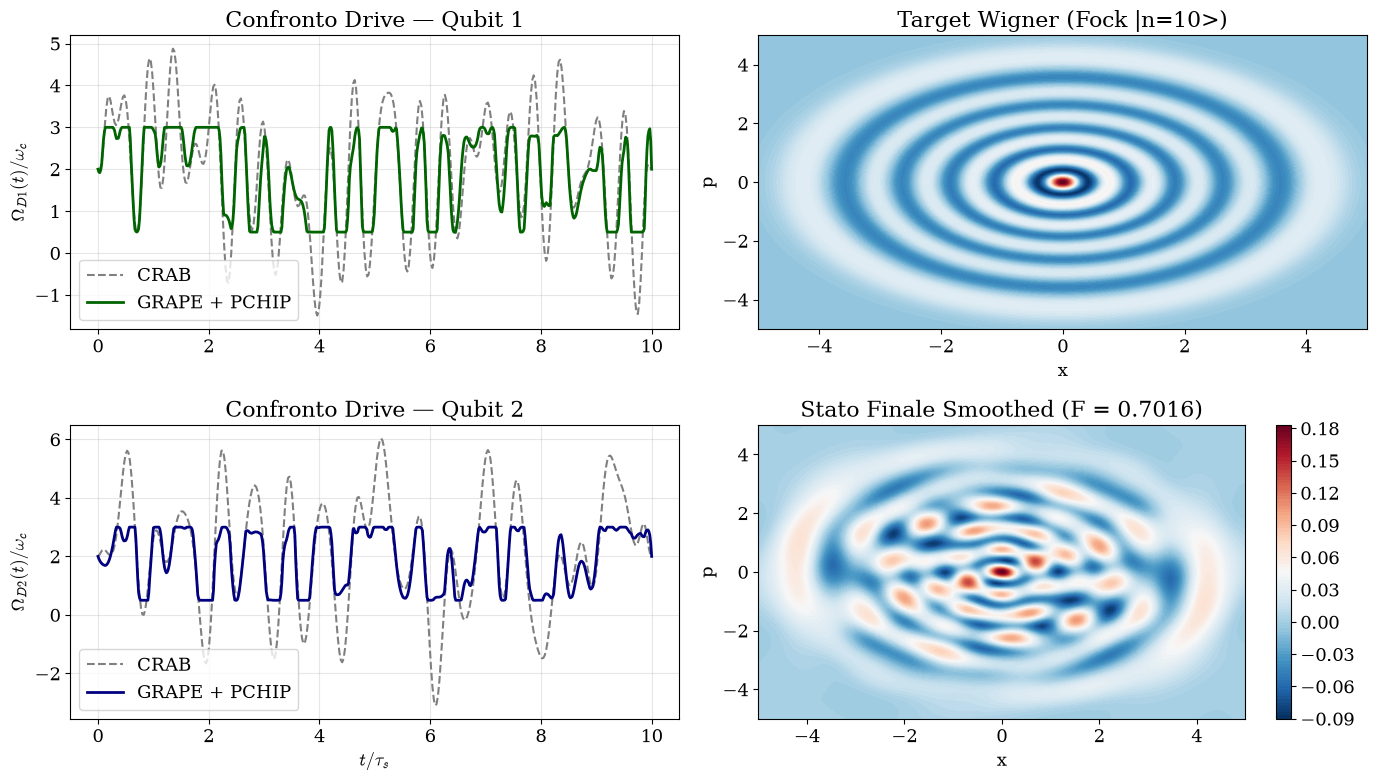

In [10]:
INTERP_NT = 600
tlist_fine = np.linspace(0, T, INTERP_NT)
dt_fine = tlist_fine[1] - tlist_fine[0]

ctrl_q1_grape = res_grape.control_pulses[0]
ctrl_q2_grape = res_grape.control_pulses[1]

# Interpolazione spline cubica PCHIP per eliminare i gradini
pchip_q1 = PchipInterpolator(tlist_grape, ctrl_q1_grape)
pchip_q2 = PchipInterpolator(tlist_grape, ctrl_q2_grape)
ctrl_q1_smooth = pchip_q1(tlist_fine)
ctrl_q2_smooth = pchip_q2(tlist_fine)

# Verifica fedeltà sul segnale liscio continuo
optimizer_fine = GRAPEOptimizer(
    H_drift=sys2q.H0,
    H_controls=sys2q.H_controls,
    T=T,
    num_tslots=INTERP_NT,
    omega_bases=omega_bases,
)
states_smooth = optimizer_fine.forward_propagation([ctrl_q1_smooth, ctrl_q2_smooth], sys2q.psi0_dm)
rho_cav_smooth = ptrace(states_smooth[-1], 0)
F_smooth = fidelity(target_state, rho_cav_smooth)
C2_smooth = compute_control_cost([ctrl_q1_smooth, ctrl_q2_smooth], dt_fine)

# Tabella riassuntiva dei 3 step
print("=" * 55)
print(f" {'Fase':<22s} {'Fedeltà F':>14s} {'Costo C^2':>12s}")
print("-" * 55)
print(f" {'1. CRAB':<22s} {F_crab:14.6f} {C2_crab:12.2f}")
print(f" {'2. GRAPE (L-BFGS-B)':<22s} {F_grape:14.6f} {C2_grape:12.2f}")
print(f" {'3. PCHIP Smoothed':<22s} {F_smooth:14.6f} {C2_smooth:12.2f}")
print("=" * 55)

# Grafico di confronto forme d'onda e Wigner finale
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(tlist / tau_s, control_q1_crab, "gray", ls="--", label="CRAB")
axes[0, 0].plot(tlist_fine / tau_s, ctrl_q1_smooth, "darkgreen", lw=2, label="GRAPE + PCHIP")
axes[0, 0].set_ylabel(r"$\Omega_{D1}(t) / \omega_c$")
axes[0, 0].set_title("Confronto Drive — Qubit 1")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].plot(tlist / tau_s, control_q2_crab, "gray", ls="--", label="CRAB")
axes[1, 0].plot(tlist_fine / tau_s, ctrl_q2_smooth, "navy", lw=2, label="GRAPE + PCHIP")
axes[1, 0].set_xlabel(r"$t / \tau_s$")
axes[1, 0].set_ylabel(r"$\Omega_{D2}(t) / \omega_c$")
axes[1, 0].set_title("Confronto Drive — Qubit 2")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[0, 1].contourf(xvec, xvec, w_target, 100, cmap="RdBu_r")
axes[0, 1].set_title(f"Target Wigner ({target_label})")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("p")

w_final_smooth = wigner(rho_cav_smooth, xvec, xvec)
im = axes[1, 1].contourf(xvec, xvec, w_final_smooth, 100, cmap="RdBu_r")
axes[1, 1].set_title(f"Stato Finale Smoothed (F = {F_smooth:.4f})")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("p")
fig.colorbar(im, ax=axes[1, 1])
plt.tight_layout()
plt.show()


### 8. (Opzionale) Caricamento Risultati Batch da `run_full_pipeline_2q.py`

In [8]:
# Se hai eseguito la pipeline su più seed da terminale con:
# python run_full_pipeline_2q.py
# i risultati vengono salvati in results_2q_pipeline_n{n_target}/results.npz.

npz_path = f"results_2q_pipeline_n{n_target}/results.npz"
if os.path.exists(npz_path):
    batch_data = np.load(npz_path)
    print(f"File {npz_path} caricato con successo!")
    print(f"Fedeltà CRAB (miglior seed): {batch_data['fidelity_crab']:.6f}")
    print(f"Fedeltà GRAPE:               {batch_data['fidelity_grape']:.6f}")
    print(f"Fedeltà Finale (smoothed):    {batch_data['fidelity_smooth']:.6f}")
else:
    print(f"Nessun file trovato in {npz_path}. Lanciando run_full_pipeline_2q.py potrai salvare qui le simulazioni lunghe.")


Nessun file trovato in results_2q_pipeline_n10/results.npz. Lanciando run_full_pipeline_2q.py potrai salvare qui le simulazioni lunghe.
